# Course: Data Science Course
# Author: Sandro Camargo <sandrocamargo@unipampa.edu.br>
# Class 04 - Polinomial Regression


To open this code in your Google Colab environment, [click here](https://colab.research.google.com/github/Sandrocamargo/data-science/blob/master/cd04_PolinomialRegression.ipynb).

## Importação de bibliotecas


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm

## Entrada de parâmetros

In [22]:
print("\n=== GERADOR DE DADOS PARA REGRESSÃO POLINOMIAL ===\n")

a = float(input("Informe o coeficiente a (x): "))
b = float(input("Informe o coeficiente b (y): "))
c = float(input("Informe o coeficiente c (z): "))
d = float(input("Informe o intercepto d: "))
e = float(input("Informe o desvio padrão do ruído (e): "))


=== GERADOR DE DADOS PARA REGRESSÃO POLINOMIAL ===

Informe o coeficiente a (x): 3
Informe o coeficiente b (y): 5
Informe o coeficiente c (z): 7
Informe o intercepto d: 11
Informe o desvio padrão do ruído (e): 15


## Geração de Dados

Este código irá gerar uma base de dados com base nos parâmetros informados anteriormente.

Os dados seguirão a fórmula:

$f(x,y,z) = ax^3 + by^2 + cz + d + \epsilon$

Onde $x, y, z$ serão valores aleatórios, e as demais variáveis serão parâmetros informados pelo usuário.

In [23]:
np.random.seed(42)

n_amostras = 2000

# Variáveis independentes aleatórias
x = np.random.uniform(-10, 10, n_amostras)
y = np.random.uniform(-10, 10, n_amostras)
z = np.random.uniform(-10, 10, n_amostras)

# Ruído branco
ruido = np.random.normal(0, e, n_amostras)

# Função verdadeira
f = a*x**3 + b*y**2 + c*z + d + ruido

## Organização dos Dados


In [24]:
X = pd.DataFrame({
    'x': x**3,
    'y': y**2,
    'z': z
})

y_target = f
print(X,y_target)

               x          y         z
0     -15.798091  22.713672  1.439918
1     732.477043  25.607891  6.108647
2      99.889518  66.017114  5.203219
3       7.682336  25.090842 -6.922002
4    -325.607735  20.802771 -7.015011
...          ...        ...       ...
1995   30.932623   1.340638  3.688707
1996  761.621908  10.969188  0.064408
1997 -640.691120   4.445999  5.302977
1998 -695.248753   0.358575 -0.294187
1999  -82.668666  45.868826 -7.012367

[2000 rows x 3 columns] [   71.56169696  2386.33222135   681.54086417 ... -1824.9636899
 -2049.79030446   -70.00647086]


## Treinamento do Modelo de Regressão Polinomial

In [25]:
modelo = LinearRegression()

modelo.fit(X, y_target)

# Predições
predicoes = modelo.predict(X)

## Resultados

In [26]:
print("\n================ RESULTADOS ================\n")

print("COEFICIENTES VERDADEIROS")
print(f"a = {a}")
print(f"b = {b}")
print(f"c = {c}")
print(f"d = {d}")

print("\nCOEFICIENTES ENCONTRADOS PELA REGRESSÃO")
print(f"a_estimado = {modelo.coef_[0]:.4f}")
print(f"b_estimado = {modelo.coef_[1]:.4f}")
print(f"c_estimado = {modelo.coef_[2]:.4f}")
print(f"d_estimado = {modelo.intercept_:.4f}")


================ RESULTADOS ================

COEFICIENTES VERDADEIROS
a = 3.0
b = 5.0
c = 7.0
d = 11.0

COEFICIENTES ENCONTRADOS PELA REGRESSÃO
a_estimado = 2.9990
b_estimado = 5.0122
c_estimado = 7.0300
d_estimado = 10.0732


## Qualidade do ajuste do modelo

In [27]:
r2 = r2_score(y_target, predicoes)

print("\nQUALIDADE DO MODELO")
print(f"R² = {r2:.6f}")


QUALIDADE DO MODELO
R² = 0.999832


## Gráfico: valores reais x estimados


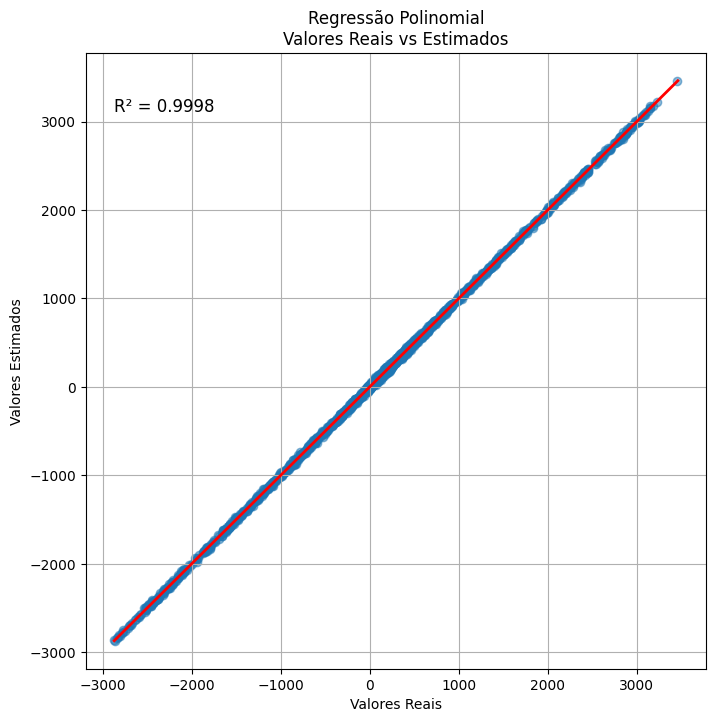

In [28]:
plt.figure(figsize=(8, 8))

# Dispersão
plt.scatter(
    y_target,
    predicoes,
    alpha=0.5
)

# Linha ideal
valor_min = min(y_target.min(), predicoes.min())
valor_max = max(y_target.max(), predicoes.max())

plt.plot(
    [valor_min, valor_max],
    [valor_min, valor_max],
    linewidth=2,
    color='red'
)

# Configurações do gráfico
plt.xlabel("Valores Reais")
plt.ylabel("Valores Estimados")
plt.title("Regressão Polinomial\nValores Reais vs Estimados")

# Mostrar R² no gráfico
plt.text(
    valor_min,
    valor_max * 0.9,
    f"R² = {r2:.4f}",
    fontsize=12
)

plt.grid(True)

plt.show()

## Interpretação didática


In [29]:
print("\nINTERPRETAÇÃO:")

if r2 > 0.95:
    print("A regressão recuperou muito bem os coeficientes.")
elif r2 > 0.80:
    print("A regressão encontrou uma boa aproximação.")
else:
    print("O ruído está dificultando a recuperação dos coeficientes.")

print("\nObserve que a regressão polinomial")
print("consegue estimar os parâmetros da função original")
print("mesmo na presença de ruído aleatório.")


INTERPRETAÇÃO:
A regressão recuperou muito bem os coeficientes.

Observe que a regressão polinomial
consegue estimar os parâmetros da função original
mesmo na presença de ruído aleatório.


## Resumo do modelo com o pacote StatsModels


In [30]:
# Adiciona coluna de intercepto
X_sm = sm.add_constant(X)

modelo_sm = sm.OLS(y_target, X_sm).fit()

print("\n================ MODEL SUMMARY ================\n")

print(modelo_sm.summary())


================ MODEL SUMMARY ================

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.959e+06
Date:                Thu, 14 May 2026   Prob (F-statistic):               0.00
Time:                        18:17:17   Log-Likelihood:                -8265.3
No. Observations:                2000   AIC:                         1.654e+04
Df Residuals:                    1996   BIC:                         1.656e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co